# 01 - Exploratory Data Analysis
Customer Segmentation & Churn Pattern Analytics — European Banking

**Goal:** Understand the data before any segmentation or churn analysis. Validate data quality, check field consistency, and get a first look at churn distribution.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Quality Checks
Confirm shape, column types, missing values, and duplicates before any segmentation or churn analysis.

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.2 MB


In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Identifier Fields
CustomerId and Surname uniquely or near-uniquely identify individual customers rather than describing any analytical property. They should never be used as features, grouping dimensions, or model inputs — confirmed here and excluded from all analysis going forward.

In [8]:
print(df['CustomerId'].nunique(), len(df))
print(df['Surname'].nunique())

10000 10000
2932


## Sample Size Check: NumOfProducts
Initial profiling suggested extreme churn rates (82–100%) among customers with 3 or 4 products. Before treating this as a genuine finding, the underlying group sizes must be checked — an extreme percentage computed from a very small group is not statistically reliable.

In [9]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [10]:
df.groupby('NumOfProducts')['Exited'].mean() * 100

NumOfProducts
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: Exited, dtype: float64

**Observation:** NumOfProducts group sizes are 1: 5,084, 2: 4,590, 3: 266, 4: 60, with corresponding churn rates shown above. The 1- and 2-product churn rates are backed by large samples and fully reliable. The 3-product churn rate (n=266) is based on a moderate sample and likely reflects a real pattern. The 4-product churn rate (n=60, ~0.6% of customers) should be treated as a low-confidence signal — the extreme percentage is plausible but not statistically robust given the small group size, and will be reported with this caveat rather than as a headline finding.

## Customer Segmentation Construction
Build the five segmentation dimensions specified in the brief: Age bands, Credit Score bands, Tenure groups, and Balance segments (Geography and Gender are already categorical and need no transformation).

In [11]:
df['Age_Band'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 100],
                         labels=['<30', '30-45', '46-60', '60+'], right=True)
df[['Age', 'Age_Band']].head()

,Age,Age_Band
0,42,30-45
1,41,30-45
2,42,30-45
3,39,30-45
4,43,30-45


In [12]:
df['CreditScore_Band'] = pd.cut(df['CreditScore'], bins=[0, 580, 700, 900],
                                  labels=['Low', 'Medium', 'High'])
df[['CreditScore', 'CreditScore_Band']].head()

,CreditScore,CreditScore_Band
0,619,Medium
1,608,Medium
2,502,Low
3,699,Medium
4,850,High


In [13]:
df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[-1, 2, 6, 20],
                              labels=['New', 'Mid-term', 'Long-term'])
df[['Tenure', 'Tenure_Group']].head()

,Tenure,Tenure_Group
0,2,New
1,1,New
2,8,Long-term
3,1,New
4,2,New


In [14]:
df['Balance_Segment'] = pd.cut(df['Balance'], bins=[-1, 0, 100000, df['Balance'].max()],
                                 labels=['Zero-balance', 'Low-balance', 'High-balance'])
df[['Balance', 'Balance_Segment']].head()

,Balance,Balance_Segment
0,0.00,Zero-balance
1,83807.86,Low-balance
2,159660.80,High-balance
3,0.00,Zero-balance
4,125510.82,High-balance


In [15]:
for col in ['Age_Band', 'CreditScore_Band', 'Tenure_Group', 'Balance_Segment']:
    print(df[col].value_counts())
    print()

Age_Band
30-45    5921
<30      1946
46-60    1647
60+       464
Name: count, dtype: int64

CreditScore_Band
Medium    4491
High      3116
Low       2393
Name: count, dtype: int64

Tenure_Group
Mid-term     3977
Long-term    3527
New          2496
Name: count, dtype: int64

Balance_Segment
High-balance    4799
Zero-balance    3617
Low-balance     1584
Name: count, dtype: int64



**Observation:** All four segmentation schemes produce reasonably sized groups (smallest: Age_Band 60+ at n=464), unlike the earlier NumOfProducts=4 group (n=60). Churn rates computed within any of these segments can be treated as statistically reliable rather than requiring a small-sample caveat.

## Churn Distribution by Segment
Compute churn rate within each segmentation dimension, then test whether the differences are statistically significant using chi-square tests.

In [16]:
for col in ['Geography', 'Gender', 'Age_Band', 'CreditScore_Band', 'Tenure_Group', 'Balance_Segment']:
    print(f"--- {col} ---")
    print(df.groupby(col)['Exited'].mean().mul(100).round(2))
    print()

--- Geography ---
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64

--- Gender ---
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64

--- Age_Band ---
Age_Band
<30       7.50
30-45    15.74
46-60    51.12
60+      24.78
Name: Exited, dtype: float64

--- CreditScore_Band ---
CreditScore_Band
Low       22.15
Medium    19.77
High      19.87
Name: Exited, dtype: float64

--- Tenure_Group ---
Tenure_Group
New          21.15
Mid-term     20.64
Long-term    19.51
Name: Exited, dtype: float64

--- Balance_Segment ---
Balance_Segment
Zero-balance    13.82
Low-balance     20.58
High-balance    25.23
Name: Exited, dtype: float64



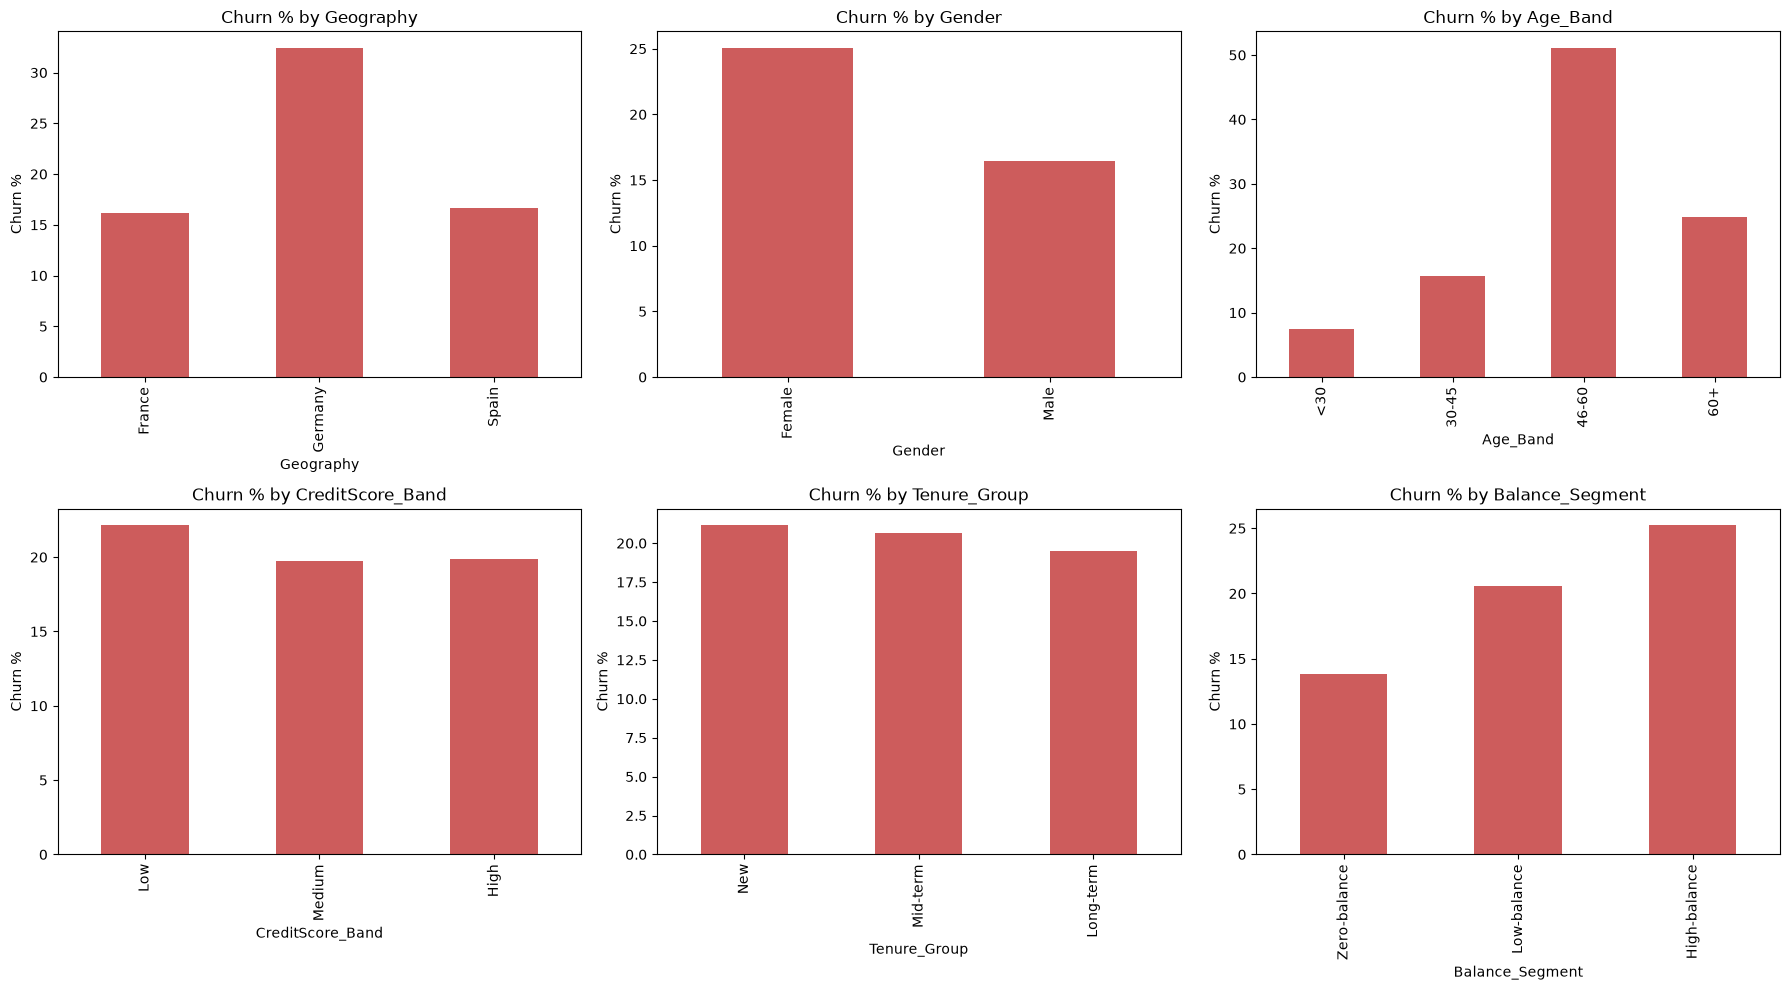

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

cols = ['Geography', 'Gender', 'Age_Band', 'CreditScore_Band', 'Tenure_Group', 'Balance_Segment']

for i, col in enumerate(cols):
    churn_by_group = df.groupby(col)['Exited'].mean() * 100
    churn_by_group.plot(kind='bar', ax=axes[i], color='indianred')
    axes[i].set_title(f'Churn % by {col}')
    axes[i].set_ylabel('Churn %')

plt.tight_layout()
plt.show()

In [18]:
from scipy.stats import chi2_contingency

for col in ['Geography', 'Gender', 'Age_Band', 'CreditScore_Band', 'Tenure_Group', 'Balance_Segment']:
    crosstab = pd.crosstab(df[col], df['Exited'])
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    print(f"{col}: chi2={chi2:.2f}, p-value={p_value:.5f}")

Geography: chi2=301.26, p-value=0.00000
Gender: chi2=112.92, p-value=0.00000
Age_Band: chi2=1241.61, p-value=0.00000
CreditScore_Band: chi2=6.14, p-value=0.04642
Tenure_Group: chi2=2.75, p-value=0.25286
Balance_Segment: chi2=165.61, p-value=0.00000


**Observation:** Chi-square tests confirm strong, statistically significant churn associations with Geography (χ²=301, p<0.001), Age_Band (χ²=1242, p<0.001 — the strongest effect, peaking at 51% in the 46-60 band before declining), Gender (χ²=113, p<0.001), and Balance_Segment (χ²=166, p<0.001, with churn counterintuitively rising alongside balance). CreditScore_Band shows a marginally significant but weak effect (χ²=6.14, p=0.046, ~2 percentage point spread). Tenure_Group shows no significant association (χ²=2.75, p=0.253) — churn does not meaningfully differ by how long a customer has been with the bank.

## Geography × Age Interaction
Germany shows the highest overall churn, and the 46-60 age band shows the highest overall churn. Check whether these effects combine (Germany's high churn concentrated in 46-60) or are independent (Germany elevated across all ages equally).

In [19]:
geo_age_churn = df.groupby(['Geography', 'Age_Band'])['Exited'].mean().mul(100).round(2)
geo_age_churn = geo_age_churn.unstack()
geo_age_churn

Age_Band,<30,30-45,46-60,60+
Geography,,,,
France,4.87,12.35,45.79,19.91
Germany,12.53,26.09,67.33,38.94
Spain,8.47,12.53,40.66,20.83


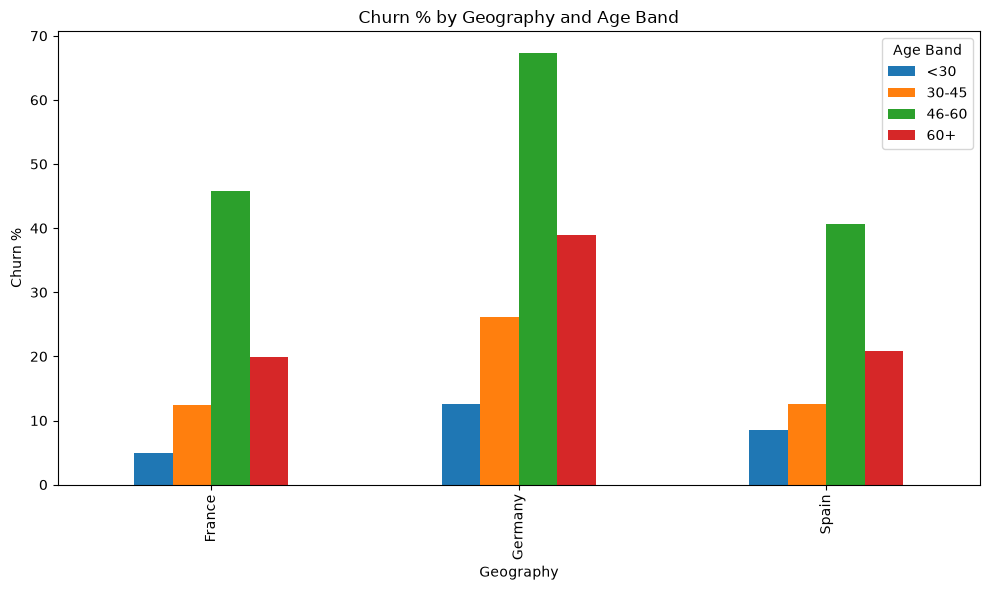

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
geo_age_churn.plot(kind='bar', ax=ax)
ax.set_title('Churn % by Geography and Age Band')
ax.set_ylabel('Churn %')
ax.legend(title='Age Band')
plt.tight_layout()
plt.show()

## Gender × Geography and Gender × Age
Check whether the gender churn gap (Female 25.07% vs Male 16.46%) holds consistently across geography and age, or is concentrated in specific subgroups.

In [21]:
gender_geo_churn = df.groupby(['Gender', 'Geography'])['Exited'].mean().mul(100).round(2).unstack()
print(gender_geo_churn)
print()

gender_age_churn = df.groupby(['Gender', 'Age_Band'])['Exited'].mean().mul(100).round(2).unstack()
print(gender_age_churn)

Geography  France  Germany  Spain
Gender                           
Female      20.34    37.55  21.21
Male        12.71    27.81  13.11

Age_Band   <30  30-45  46-60    60+
Gender                             
Female    9.93  19.67  57.30  30.05
Male      5.51  12.60  44.97  20.32


**Observation:** Germany shows elevated churn across every age band (not concentrated in one), confirming Geography and Age act as independent, stacking risk factors — Germany's 46-60 band reaches 67.33% churn, the highest cell in the dataset. The gender gap (Female > Male) also holds consistently across all countries and age bands, with Germany showing the largest absolute gender gap (~10 points). Female customers aged 46-60 show 57.30% churn, the second-highest cell. The compound profile of an older German woman represents the highest concentration of churn risk found in this analysis.